In [ ]:
#All the libraries used in the notebook
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skopt import gp_minimize
from skopt.space import Real
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("data/all_data_merged.csv", parse_dates=["DATE"])
df = df.sort_values(["DISTRICT", "DATE"]).reset_index(drop=True)

#One-hot encoding the DISTRICT column
ohe = OneHotEncoder(sparse_output=False)
district_onehot = ohe.fit_transform(df[["DISTRICT"]])

#Needed features for the model
X_base = df[["WEATHER_CONDITION","SPECIAL_DAY","DAY_OF_WEEK_NUM",
             "POPULATION","RAILWAY_STATIONS","BUS_STATIONS"]].values
#Concatenating base features with one-hot encoded district features
X_raw = np.hstack([X_base, district_onehot])
#Congestion target variable
y_raw = df["CONGESTION"].values.reshape(-1, 1)

#Scaling the features and target variable
sx, sy = MinMaxScaler(), MinMaxScaler()
Xs = sx.fit_transform(X_raw)
ys = sy.fit_transform(y_raw)

#Sequential data for LSTM model
seq_len = 10
Xs_seq, ys_seq, districts_seq = [], [], []
for i in range(len(Xs) - seq_len):
    Xs_seq.append(Xs[i:i+seq_len])  
    ys_seq.append(ys[i+seq_len])    
    districts_seq.append(df["DISTRICT"].iloc[i+seq_len])  
Xs_seq, ys_seq, districts_seq = np.array(Xs_seq), np.array(ys_seq), np.array(districts_seq)

In [ ]:
#Base model class for LSTM regression
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_dim=2, n_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_dim, n_layers, batch_first=True)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h, _ = self.lstm(x)
        return self.out(h[:, -1, :])

#Flattening and unflattening functions for model parameters
def flatten_weights(model):
    #Flatten all model parameters into a single 1D numpy array
    return np.concatenate([p.detach().cpu().numpy().ravel() for p in model.parameters()])

def unflatten_weights(model, vec):
    #Assign values from a 1D numpy array back to the model parameters
    idx = 0
    for p in model.parameters():
        numel = p.numel()
        chunk = vec[idx:idx+numel].reshape(p.shape)
        p.data.copy_(torch.from_numpy(chunk))
        idx += numel

In [ ]:
#Fitness function for the LSTM model
def make_fitness(X_train, y_train, device="cpu"):
    model = LSTMRegressor(n_features=X_train.shape[-1], hidden_dim=2, n_layers=1).to(device)
    dim = sum(p.numel() for p in model.parameters())
    #Takes a flattened weight vector and returns the loss
    def fitness(w):
        unflatten_weights(model, np.array(w))
        Xb = torch.tensor(X_train, dtype=torch.float32).to(device)
        yb = torch.tensor(y_train, dtype=torch.float32).to(device)
        preds = model(Xb).squeeze()
        loss = nn.MSELoss()(preds, yb.squeeze()).item()
        return loss
    return fitness, dim, model

fitness, dim, model = make_fitness(Xs_seq, ys_seq)

In [ ]:
space = [Real(-1, 1) for _ in range(dim)]
init_params = flatten_weights(model).tolist() 

#Initializing the model with random weights
res = gp_minimize(
    func=fitness,
    dimensions=space,
    n_calls=25,          
    x0=init_params,
    n_random_starts=8,
    random_state=42
)

#Finding the best weights and best loss
best_weights = np.array(res.x)
unflatten_weights(model, best_weights)
print("Best loss:", res.fun)

Best loss: 0.047636453062295914


In [ ]:
results = []
districts = np.unique(districts_seq)

#Looping through each district
for district in districts:
    idxs = districts_seq == district
    X_d = Xs_seq[idxs]
    y_d = ys_seq[idxs]

    #Skipping if no data for this district
    if len(X_d) == 0:
        continue

    #Convert,ng to tensor and making predictions
    Xb = torch.tensor(X_d, dtype=torch.float32)
    with torch.no_grad():
        preds = model(Xb).squeeze().numpy()

    #Inverse transform predictions and true values to original scale 
    preds_inv = sy.inverse_transform(preds.reshape(-1, 1))
    y_true_inv = sy.inverse_transform(y_d.reshape(-1, 1))

    #Calculating evaluation metrics
    mse = mean_squared_error(y_true_inv, preds_inv)
    mae = mean_absolute_error(y_true_inv, preds_inv)
    std_pred = preds_inv.std()  
    std_true = y_true_inv.std() 
    
    #Storing the results
    results.append({
        "District": district,
        "MSE": mse,
        "MAE": mae,
        "Pred Std": std_pred,
        "True Std": std_true
    })

df_results = pd.DataFrame(results)
sorted_df = df_results.sort_values("MSE")

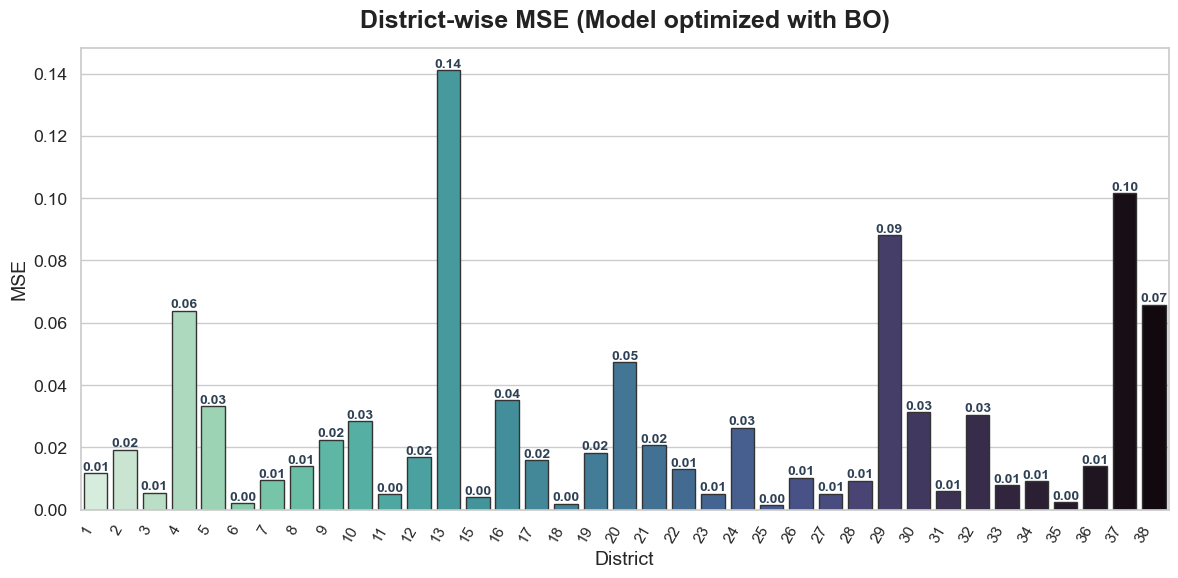

In [ ]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)

plt.figure(figsize=(12, 6))

#Creating a barplot for district-wise MSE
bar = sns.barplot(x="District", y="MSE", data=sorted_df, palette="mako_r", edgecolor=".2")

plt.title("District-wise MSE (Model optimized with BO)", weight="bold", fontsize=18, color="#222222", pad=15)
plt.ylabel("MSE", fontsize=14)
plt.xlabel("District", fontsize=14)
plt.xticks(rotation=60, ha="right", fontsize=11)
plt.tight_layout()
#Showing each bar with its MSE value
for p in bar.patches:
    bar.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                 ha="center", va="bottom", fontsize=10, color="#2e4053", weight="bold")
plt.show()

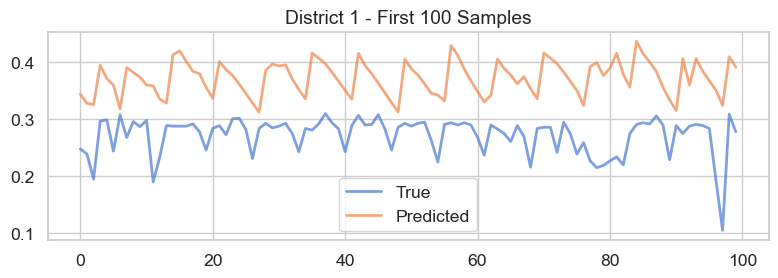

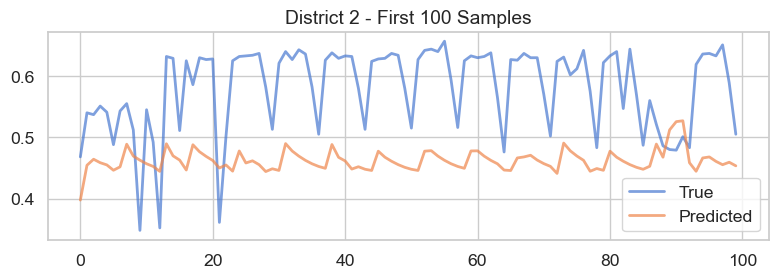

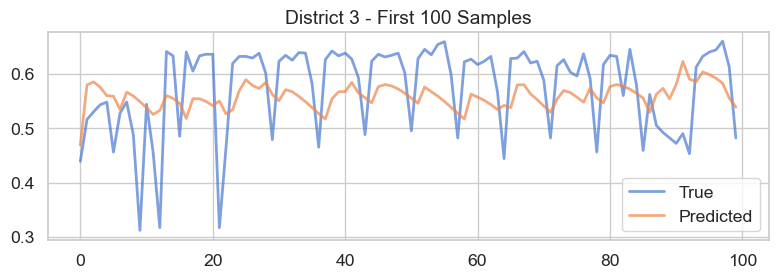

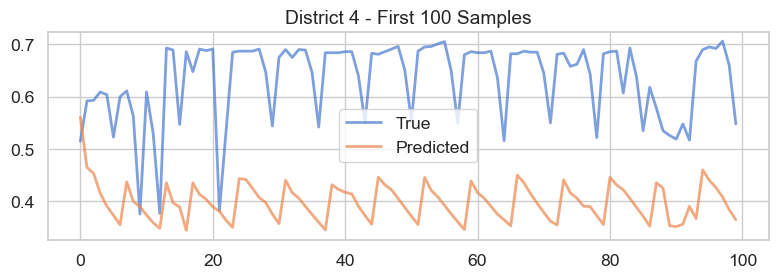

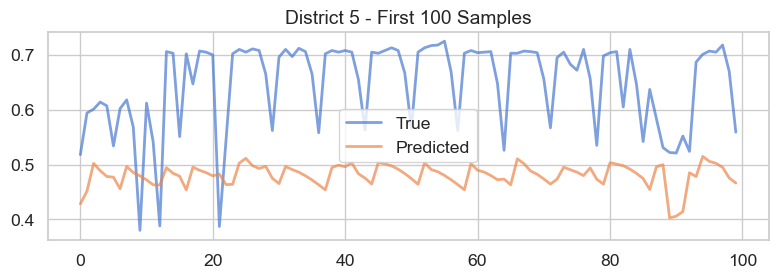

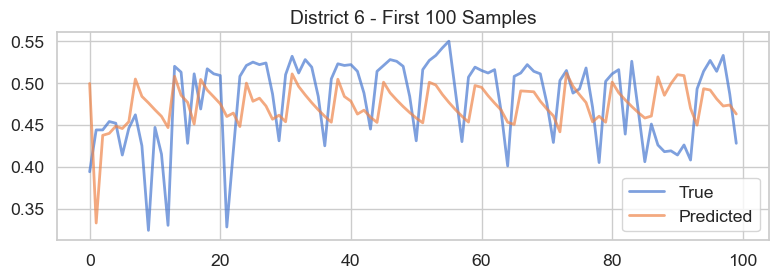

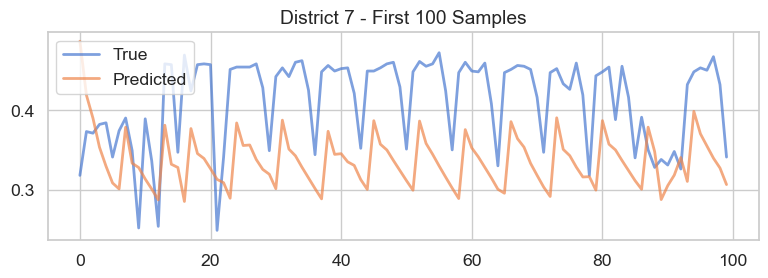

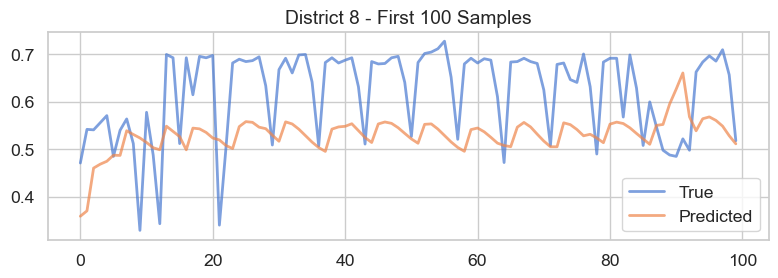

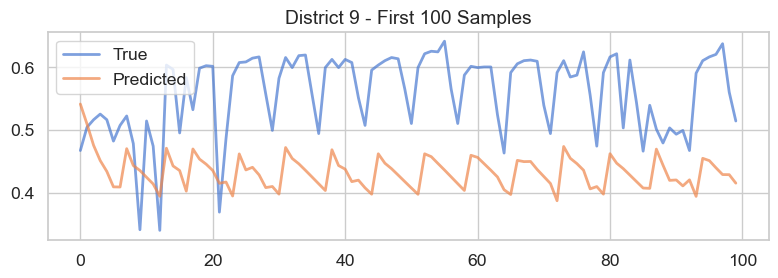

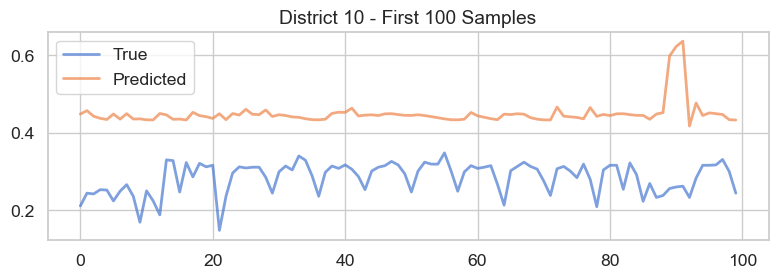

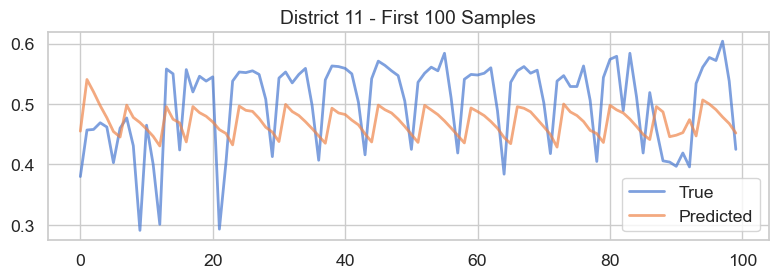

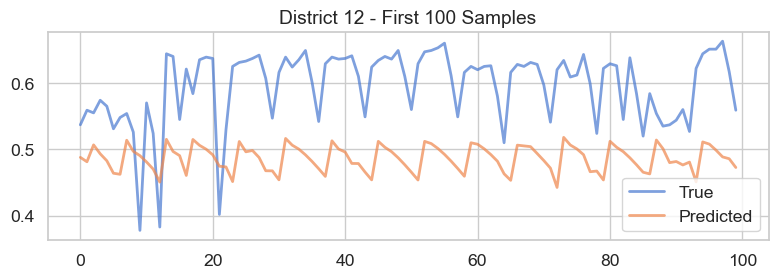

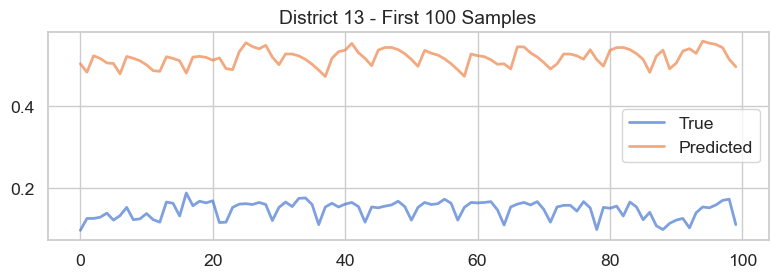

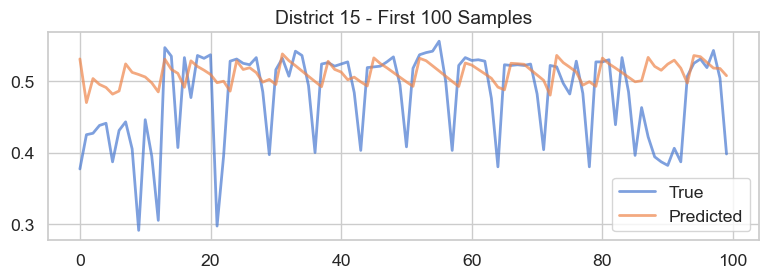

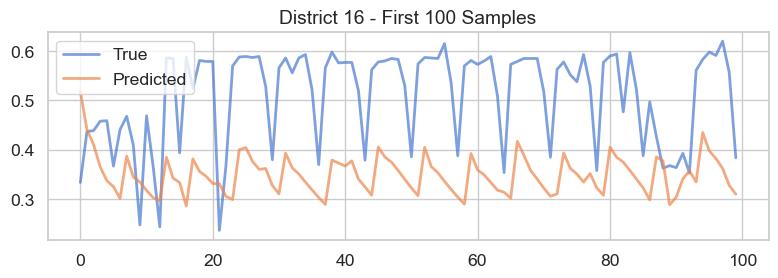

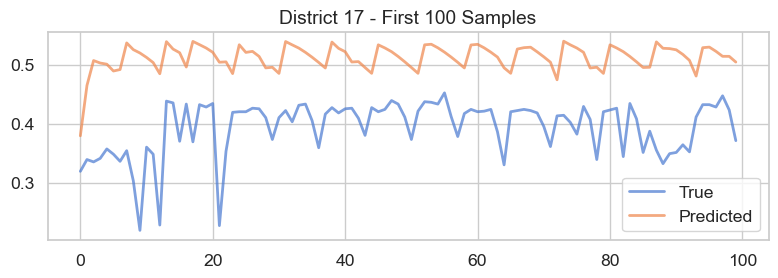

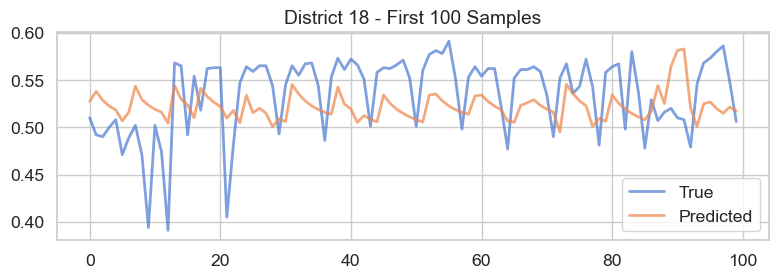

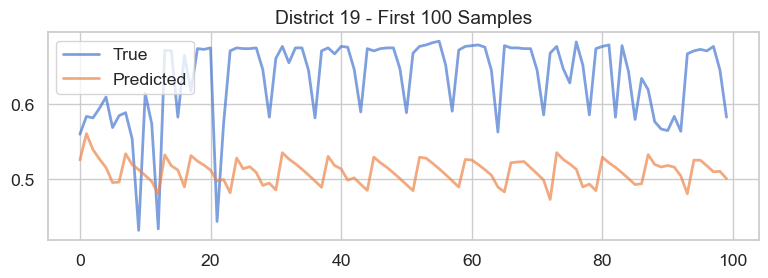

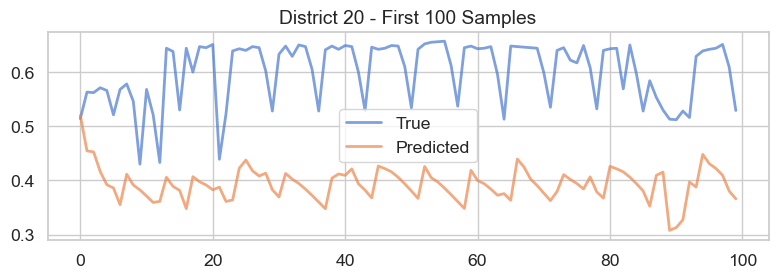

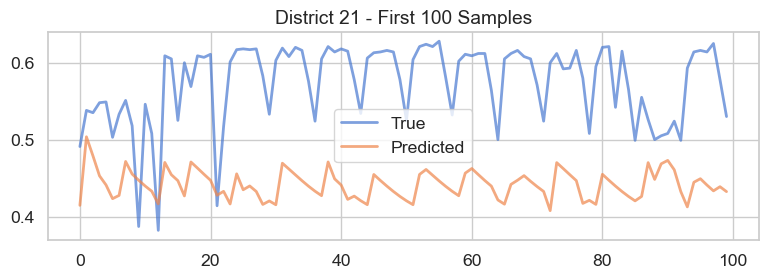

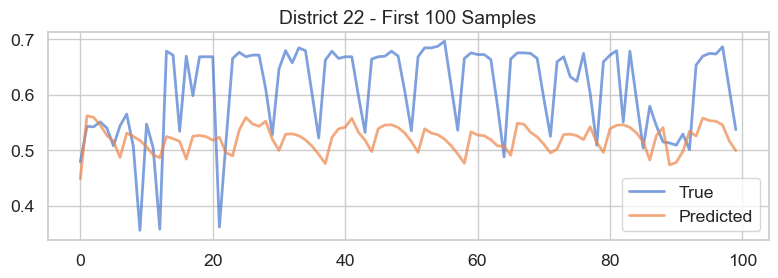

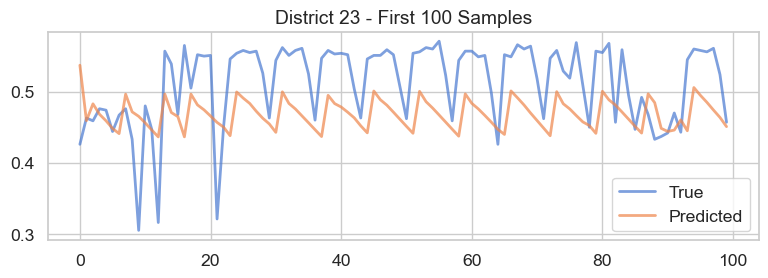

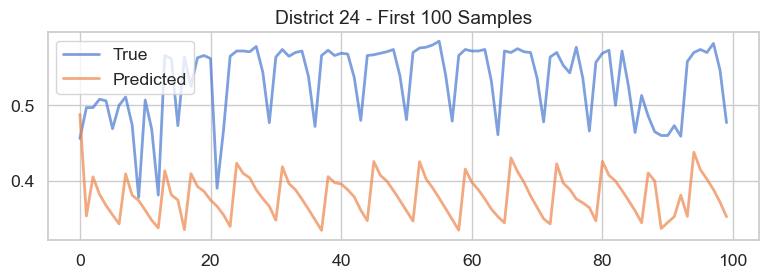

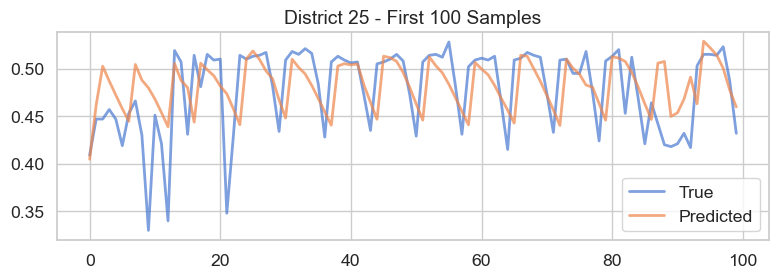

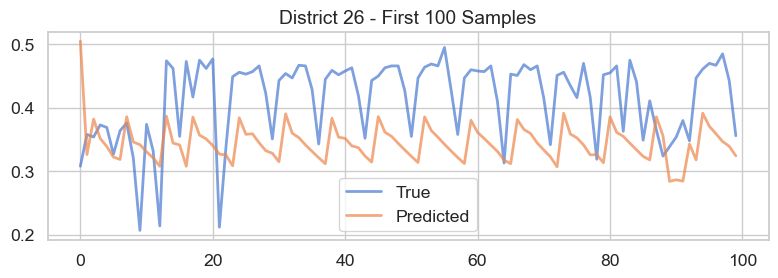

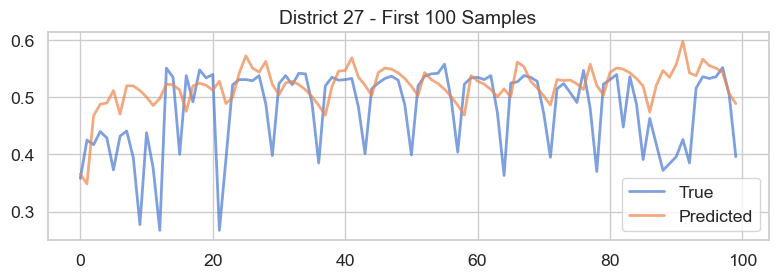

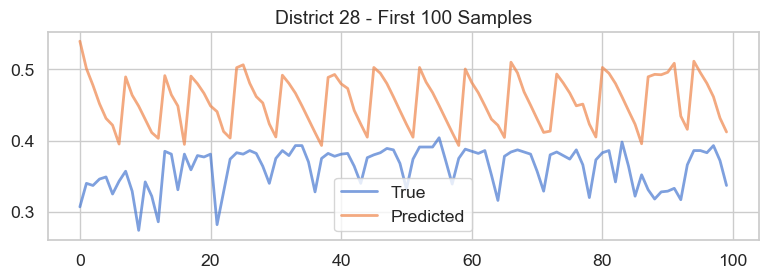

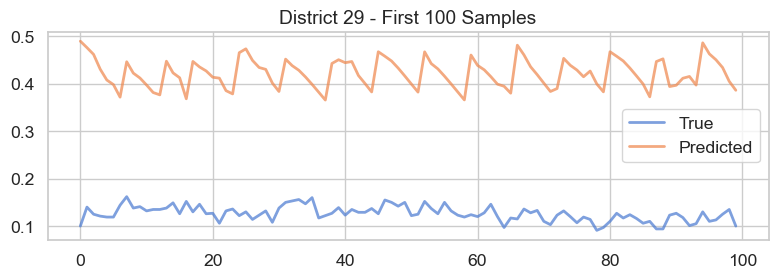

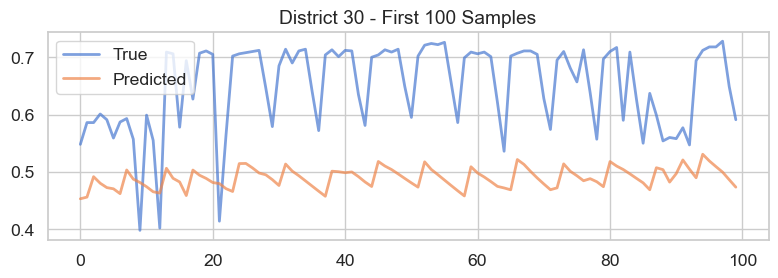

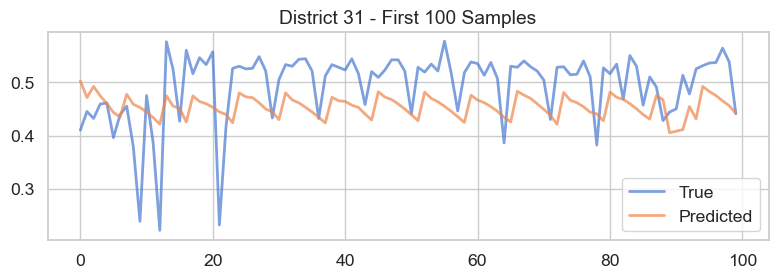

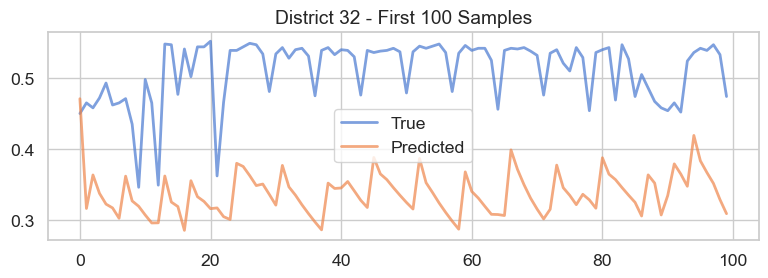

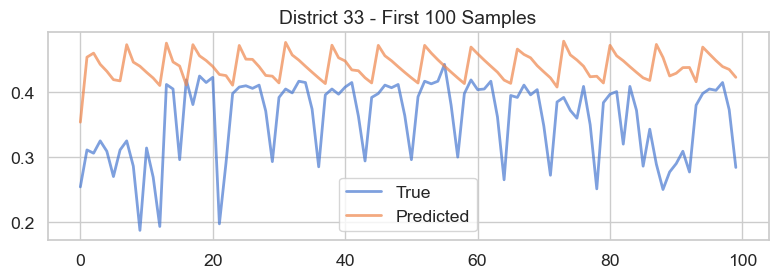

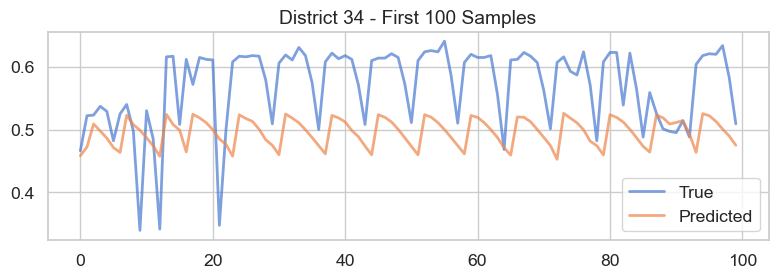

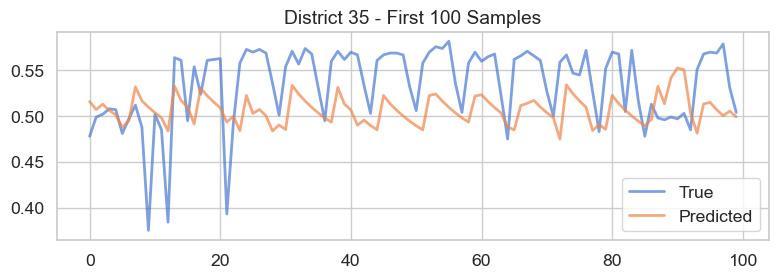

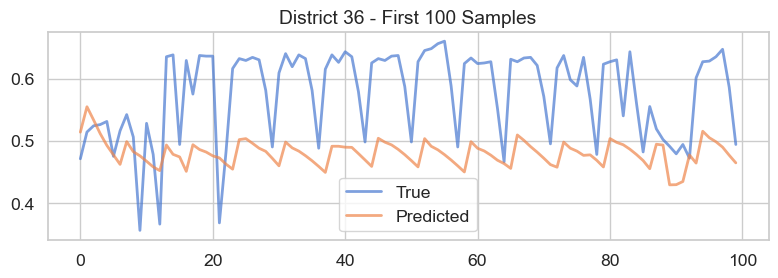

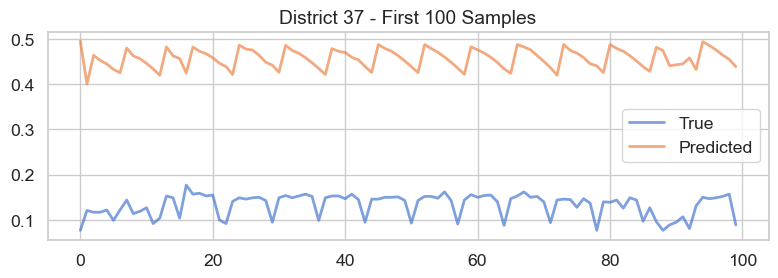

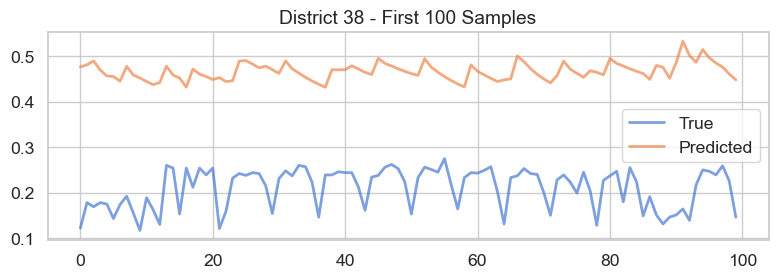

In [ ]:
#Visualizing predictions vs true values for each district
all_results = []

model.eval()
districts = np.unique(districts_seq)

for district in districts:
    idxs = districts_seq == district
    X_d = Xs_seq[idxs]
    y_d = ys_seq[idxs]

    if len(X_d) == 0:
        continue

    Xb = torch.tensor(X_d, dtype=torch.float32).to(model.device if hasattr(model, "device") else "cpu")
    with torch.no_grad():
        preds = model(Xb).cpu().squeeze().numpy()
    preds_inv = sy.inverse_transform(preds.reshape(-1, 1)).flatten()
    y_true_inv = sy.inverse_transform(y_d.reshape(-1, 1)).flatten()

    #Storing each district's predictions and true values
    for i in range(len(preds_inv)):
        all_results.append({
            "district": district,
            "seq_idx": i,
            "true": y_true_inv[i],
            "predicted": preds_inv[i]
        })

    #Plotting true vs predicted values for first 100 samples
    plt.figure(figsize=(8, 3))
    plt.plot(y_true_inv[:100], label="True", alpha=0.7, linewidth=2)
    plt.plot(preds_inv[:100], label="Predicted", alpha=0.7, linewidth=2)
    plt.title(f"District {district} - First 100 Samples")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
#Experimenting with different values for n_calls and n_random_starts in Bayesian Optimization
n_calls_list = [15, 25, 40] 
n_random_starts_list = [4, 8, 12]

experiment_results = []

for n_calls in n_calls_list:
    for n_random_starts in n_random_starts_list:
        #Initializing new model and fit. funct. for each experiment
        model = LSTMRegressor(n_features=Xs_seq.shape[-1], hidden_dim=2, n_layers=1)
        fitness, dim, model = make_fitness(Xs_seq, ys_seq)
        space = [Real(-1, 1) for _ in range(dim)]
        init_params = flatten_weights(model).tolist()
        
        #Current parameters
        res = gp_minimize(
            func=fitness,
            dimensions=space,
            n_calls=n_calls,
            x0=init_params,
            n_random_starts=n_random_starts,
            random_state=42
        )
        best_weights = np.array(res.x)
        unflatten_weights(model, best_weights)
        
        #Evaluating the model
        mse_list = []
        for district in np.unique(districts_seq):
            idxs = districts_seq == district
            X_d = Xs_seq[idxs]
            y_d = ys_seq[idxs]
            if len(X_d) == 0:
                continue
            Xb = torch.tensor(X_d, dtype=torch.float32)
            with torch.no_grad():
                preds = model(Xb).squeeze().numpy()
            preds_inv = sy.inverse_transform(preds.reshape(-1,1))
            y_true_inv = sy.inverse_transform(y_d.reshape(-1,1))
            mse = mean_squared_error(y_true_inv, preds_inv)
            mse_list.append(mse)
        mse_mean = np.mean(mse_list)
        mse_min = np.min(mse_list)
        mse_max = np.max(mse_list)

        #Storing results
        experiment_results.append({
            "n_calls": n_calls,
            "n_random_starts": n_random_starts,
            "best_loss": res.fun,
            "mse_mean": mse_mean,
            "mse_min": mse_min,
            "mse_max": mse_max
        })
        print(f"n_calls={n_calls}, n_random_starts={n_random_starts} => best_loss={res.fun:.4f}, mse_mean={mse_mean:.4f}")

#a dataframe to show results
df_exp = pd.DataFrame(experiment_results)
display(df_exp)

n_calls=15, n_random_starts=4 => best_loss=0.0515, mse_mean=0.0276
n_calls=15, n_random_starts=8 => best_loss=0.0591, mse_mean=0.0316
n_calls=15, n_random_starts=12 => best_loss=0.0577, mse_mean=0.0309
n_calls=25, n_random_starts=4 => best_loss=0.0542, mse_mean=0.0290
n_calls=25, n_random_starts=8 => best_loss=0.0447, mse_mean=0.0239
n_calls=25, n_random_starts=12 => best_loss=0.0559, mse_mean=0.0299
n_calls=40, n_random_starts=4 => best_loss=0.0475, mse_mean=0.0254
n_calls=40, n_random_starts=8 => best_loss=0.0468, mse_mean=0.0250
n_calls=40, n_random_starts=12 => best_loss=0.0534, mse_mean=0.0285


,n_calls,n_random_starts,best_loss,mse_mean,mse_min,mse_max
0,15,4,0.051486,0.027553,0.002504,0.169179
1,15,8,0.059092,0.031566,0.005049,0.151899
2,15,12,0.057682,0.030854,0.002002,0.201477
3,25,4,0.054222,0.029005,0.001835,0.208806
4,25,8,0.044724,0.023913,0.001795,0.123840
5,25,12,0.055950,0.029932,0.001296,0.186263
6,40,4,0.047523,0.025416,0.001252,0.145251
7,40,8,0.046798,0.025022,0.001340,0.147980
8,40,12,0.053395,0.028516,0.001764,0.107580
